In [1]:
# python
import os
import sys
import importlib
# columnar analysis
from coffea import processor
from coffea.nanoevents import NanoAODSchema
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(os.getcwd()).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import utilities, sidm_processor, scaleout, llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(utilities)
importlib.reload(sidm_processor)
importlib.reload(scaleout)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
%matplotlib inline
from hist import intervals
import coffea.util
# import numpy as np
import mplhep as hep
import numpy as np
import warnings

In [2]:
import yaml
yaml_file_path = '../../configs/ntuples/signal_2mu2e_v10.yaml'
# Open and read the YAML file
with open(yaml_file_path, 'r') as file:
    data = yaml.safe_load(file)
signals_all = list(data["llpNanoAOD_v2"]["samples"].keys())
# for x in range(len(signals_all)):
#     # if x == 0:
#     print("'" + signals_all[x] + "',")


In [3]:
QCD=[ 
     "QCD_Pt15To20", 
     "QCD_Pt20To30",
     "QCD_Pt30To50",
     "QCD_Pt50To80",
     "QCD_Pt80To120",
     "QCD_Pt120To170",
    "QCD_Pt170To300",
    "QCD_Pt300To470",
     "QCD_Pt470To600",
     "QCD_Pt600To800",
    "QCD_Pt800To1000",
     "QCD_Pt1000",
    ]
DY = [ 
    "DYJetsToMuMu_M10to50",
    "DYJetsToMuMu_M50",
     ]
TT = [ 
    "TTJets",
     ]

DB= [
    "WW",
    "WZ", 
    "ZZ"]

bgs=  TT + QCD + DY + DB 





In [4]:
S = [
 '2Mu2E_500GeV_0p25GeV_0p004mm',
'2Mu2E_500GeV_0p25GeV_4p0mm',
'2Mu2E_500GeV_5p0GeV_0p08mm',
'2Mu2E_500GeV_5p0GeV_80p0mm',

]

In [5]:
from coffea.processor import accumulate
def sum_hist(samples_list, folder_name):
    summed_out = None
    for x in samples_list:
        output = coffea.util.load(f"{folder_name}/output_{x}.coffea")
        hists = output["out"][x]["hists"]
        if summed_out is None:
            summed_out = hists.copy()
        else:
            summed_out = accumulate ([hists, summed_out])
    return summed_out

In [6]:

channel_name = "base_ljObjCut_ljIso_1lj"
hist_collection = "displacement_base"
dir_name = channel_name + hist_collection



output_signal = coffea.util.load(f"{dir_name}/output_signal.coffea" )
summed_QCD = sum_hist(QCD, dir_name)
summed_TT  = sum_hist(TT, dir_name)
summed_DY  = sum_hist(DY, dir_name)
summed_DB  = sum_hist(DB, dir_name)

summed_DB.keys()

dict_keys(['mulj_egmlj_invmass', 'mulj_egmlj_invmass_pixelHits_lostHits', 'mulj_egmlj_invmass_trkLayers_lostHits', '1pf_mulj_egmlj_invmass', 'pf_mulj_egmlj_invmass', 'pf_dsa_mulj_egmlj_invmass', 'dsa_mulj_egmlj_invmass', '1pf_mulj_egmlj_invmass_pixelHits2', '1pf_mulj_egmlj_invmass_pixelHits1', '1pf_mulj_egmlj_invmass_pixelHits0', '1pf_mulj_egmlj_invmass_pixelHits3', '1pf_mulj_egmlj_invmass_pixelHits4', '1pf_mulj_egmlj_invmass_trkLayers10', '1pf_mulj_egmlj_invmass_trkLayers12', '1pf_mulj_egmlj_invmass_trkLayers11', '1pf_mulj_egmlj_invmass_trkLayers9', '1pf_mulj_egmlj_invmass_trkLayers8', '1pf_mulj_egmlj_invmass_trkLayers7', 'pf_mulj_egmlj_invmass_pixelHits', 'pf_dsa_mulj_egmlj_invmass_pixelHits', 'pf_mulj_egmlj_invmass_trkLayers', 'pf_dsa_mulj_egmlj_invmass_trkLayers', 'mulj_1e_lj_invmass', 'mulj_1e_lj_invmass_lostHits1', 'mulj_1e_lj_invmass_lostHits0', 'mulj_1e_lj_invmass_lostHits2', 'mulj_e_lj_invmass', 'mulj_eg_lj_invmass', 'mulj_g_lj_invmass', 'mulj_e_lj_invmass_lostHits', 'mulj_eg_

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


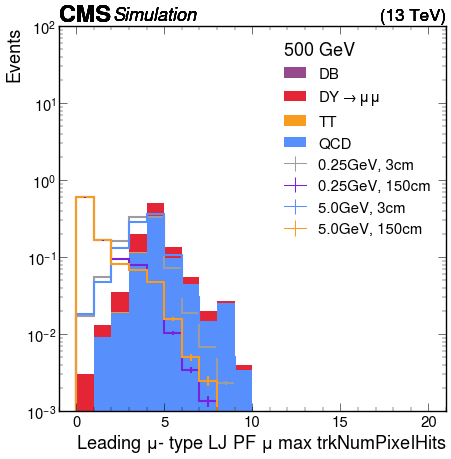

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


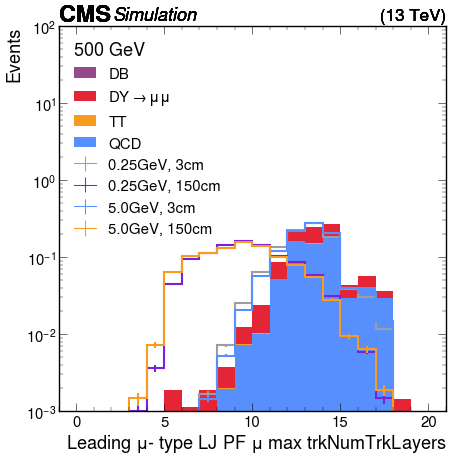

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


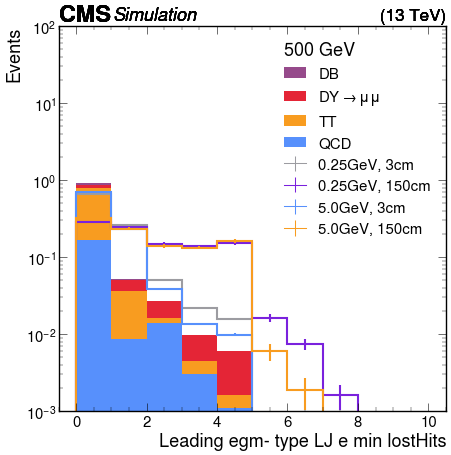

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


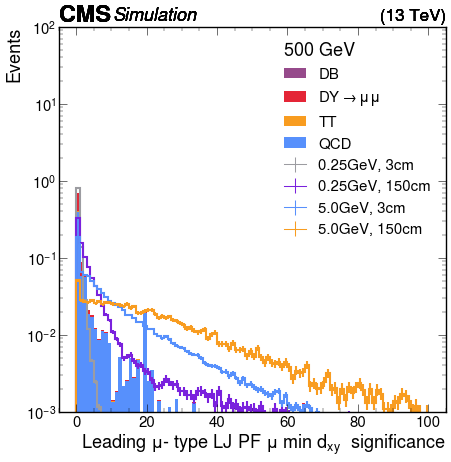

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


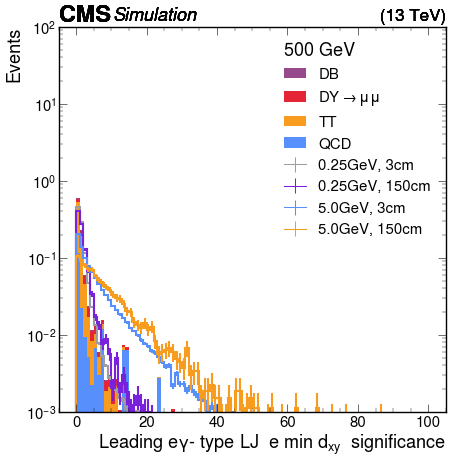

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


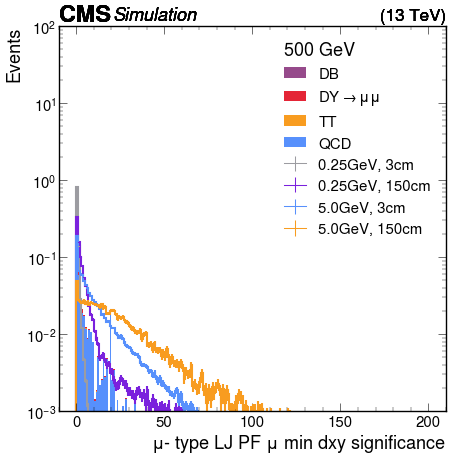

2Mu2E_500GeV_0p25GeV_0p04mm
2Mu2E_500GeV_0p25GeV_2p0mm
2Mu2E_500GeV_5p0GeV_0p8mm
2Mu2E_500GeV_5p0GeV_40p0mm


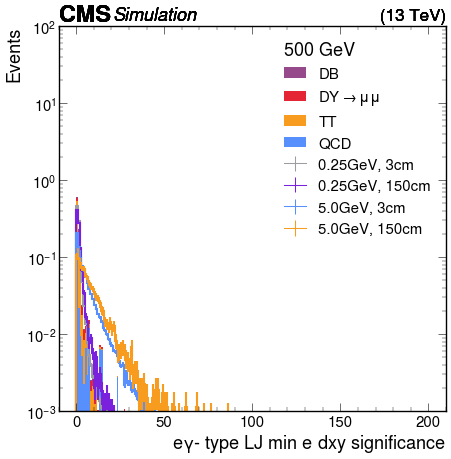

In [7]:


histogram_list  = [ 
 
# "mu_lj_n",
# "egm_lj_n", 
# "leading_mu_lj_muon_max_trkNumPixelHits",
# "leading_pf_mu_lj_pfMu_max_trkNumPixelHits", 
# "leading_pf_dsa_mu_lj_pfMu_max_trkNumPixelHits",
# "leading_mu_lj_pfMu_max_trkNumPixelHits",
"leading_mu_lj_pfMu_max_trkNumPixelHits",
# "leading_mu_lj_muon_max_trkNumTrkLayers",
"leading_mu_lj_pfMu_max_trkNumTrkLayers",
# "leading_pf_mu_lj_pfMu_max_trkNumTrkLayers",
# "leading_pf_dsa_mu_lj_pfMu_max_trkNumTrkLayers",
"leading_egm_lj_electron_min_lostHits",
"leading_mu_lj_pf_muon_min_dxy_signi",
"leading_egm_lj_electron_min_dxy_signi",
    "mu_lj_pfMuon_min_dxy_signi",
    "egm_lj_electron_min_dxy_signi"

# "leading_e_lj_electron_min_lostHits",
# "leading_eg_lj_electron_min_lostHits",

]
S = [
   
'2Mu2E_500GeV_0p25GeV_0p04mm',

'2Mu2E_500GeV_0p25GeV_2p0mm',
'2Mu2E_500GeV_5p0GeV_0p8mm',
'2Mu2E_500GeV_5p0GeV_40p0mm',

]
# sum_bg = sum_bgs_hist(QCD, histogram_name,channel_name )
for i, histogram_name in enumerate(histogram_list):
    # print(i, histogram_name, title_list[i])
    # plt.figure(figsize=(10, 10))
    sum_bg_qcd = summed_QCD[histogram_name][channel_name, :]
    sum_bg_tt = summed_TT[histogram_name][channel_name, :]
    sum_bg_dy = summed_DY[histogram_name][channel_name, :]
    sum_bg_db = summed_DB[histogram_name][channel_name, :]
    
    utilities.plot(
    [sum_bg_qcd, sum_bg_tt,
      sum_bg_dy, sum_bg_db
    ],
    flow="none",
    yerr=True,
    density=True,
    histtype="fill",
    # color=["#A9A9A9", "#FFB6C1",
    #        "#9ECAE1"
    #       ],
    label=["QCD", "TT",
         r"DY$\rightarrow \mu\mu$",
         "DB" ],
    stack=True,
)
    labels = ["3cm", "150cm", "3cm", "150cm"]
    for i, s in enumerate(S):
        print(s)
        parts = s.split("_")
        mass = parts[1]
        zd_mass = parts[2].replace("p", ".")
        ctau = parts[3].replace("p", ".").replace("mm", "")
        label =  zd_mass + ", " + labels[i]
        histogram = output_signal["out"][s]["hists"][histogram_name][channel_name, :]

        utilities.plot(histogram, flow ="none", yerr=True, density=True, label=label,
                       linewidth=3,
                      )
    # hep.label.exp_text(text="500 GeV ", loc=3) 
    plt.yscale("log")
    # plt.title(histogram_name)
    plt.ylabel("Events")
    plt.legend(title = "500 GeV", alignment="left")
    plt.ylim(1e-3, 1e2)
    plt.savefig(f"{dir_name}/{histogram_name}.png")
    plt.show()
    # plt.savefig("/home/cms-jovyan/SIDM/plots/" + histogram_name + ".png")
    plt.close()